In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision.datasets import CIFAR10

In [2]:
# Datasets & DataLoaders
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = CIFAR10(root="./data", train=True, download=True, transform=transform)
testset = CIFAR10(root="./data", train=False, download=True, transform=transform)

classes = trainset.classes
print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [3]:
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64)

### Build the CNN

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # kernel size = 2, stride = 2

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2) ,

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(4*4*128, 256),
            nn.ReLU(),

            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1) # flattening
        x = self.fc_layers(x)

        return x

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
print(device)

cpu


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

### Training the CNN

In [7]:
epochs = 30
train_losses = []  # track loss per epoch for plotting

for epoch in range(epochs):
    epoch_training_loss = 0.0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        output = model.forward(images) # FP
        loss = criterion(output, labels) # loss fnx
        loss.backward() # BP
        optimizer.step() # update params

        epoch_training_loss += loss.item()

    avg_loss = epoch_training_loss / len(trainloader)
    train_losses.append(avg_loss)
    print(f"epoch={epoch+1}/{epochs} & loss={avg_loss}")

epoch=1/30 & loss=1.3889621151682665
epoch=2/30 & loss=0.9528615284911202
epoch=3/30 & loss=0.7574415872316531
epoch=4/30 & loss=0.6315154262134791
epoch=5/30 & loss=0.5233086613209351
epoch=6/30 & loss=0.43038074338756255
epoch=7/30 & loss=0.34849153329496796
epoch=8/30 & loss=0.27067707291306436
epoch=9/30 & loss=0.2114231356650667
epoch=10/30 & loss=0.16528461340938688
epoch=11/30 & loss=0.1285168544729919
epoch=12/30 & loss=0.11799823746318593
epoch=13/30 & loss=0.10169825343119786
epoch=14/30 & loss=0.09366692391121784
epoch=15/30 & loss=0.09149542367032222
epoch=16/30 & loss=0.07912181230122581
epoch=17/30 & loss=0.06478004053186225
epoch=18/30 & loss=0.06786641341936596
epoch=19/30 & loss=0.07896399742666432
epoch=20/30 & loss=0.07299032324970917
epoch=21/30 & loss=0.057693474808894814
epoch=22/30 & loss=0.061193423951454995
epoch=23/30 & loss=0.06741463968462115
epoch=24/30 & loss=0.05674914560471888
epoch=25/30 & loss=0.058028947804933007
epoch=26/30 & loss=0.05941331813551361

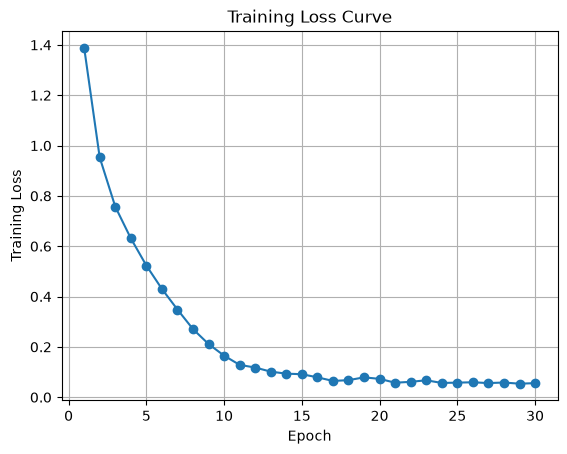

In [8]:
import matplotlib.pyplot as plt

plt.plot(range(1, epochs+1), train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

In [9]:
# Save the trained model weights so we can reload later without retraining
torch.save(model.state_dict(), "cnn_cifar10.pth")
print("Model saved to cnn_cifar10.pth")

Model saved to cnn_cifar10.pth


### Evaluate the CNN

In [10]:
# Overall accuracy on the test set

correct_labels = 0
total_labels = 0

model.eval()

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model.forward(images)
        _, predicted  = torch.max(outputs, 1)

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)

print(f"accuracy = {correct_labels / total_labels * 100}")

accuracy = 74.95


In [11]:
# Per-class accuracy - reveals which classes the model struggles with

class_correct = [0]*10
class_total = [0]*10

model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct_mask = (predicted == labels)
        for i in range(labels.size(0)):
            label = labels[i]
            class_correct[label] += correct_mask[i].item()
            class_total[label] += 1

for i in range(10):
    print(f"{classes[i]:10s}: {100 * class_correct[i] / class_total[i]:.2f}%")

airplane  : 78.10%
automobile: 78.70%
bird      : 64.90%
cat       : 56.30%
deer      : 70.30%
dog       : 68.10%
frog      : 81.90%
horse     : 81.80%
ship      : 84.80%
truck     : 84.60%


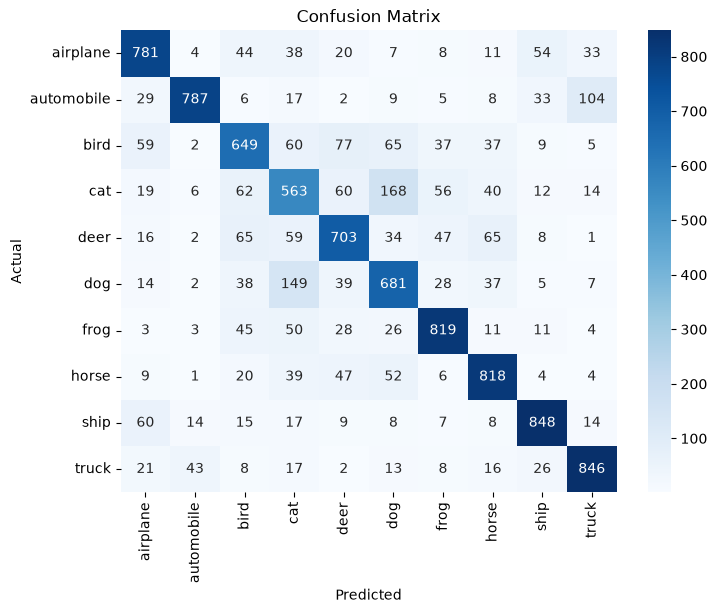

              precision    recall  f1-score   support

    airplane       0.77      0.78      0.78      1000
  automobile       0.91      0.79      0.84      1000
        bird       0.68      0.65      0.66      1000
         cat       0.56      0.56      0.56      1000
        deer       0.71      0.70      0.71      1000
         dog       0.64      0.68      0.66      1000
        frog       0.80      0.82      0.81      1000
       horse       0.78      0.82      0.80      1000
        ship       0.84      0.85      0.84      1000
       truck       0.82      0.85      0.83      1000

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.75      0.75      0.75     10000



In [12]:
# Confusion matrix - shows exactly which classes get confused with each other
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(all_labels, all_preds, target_names=classes))

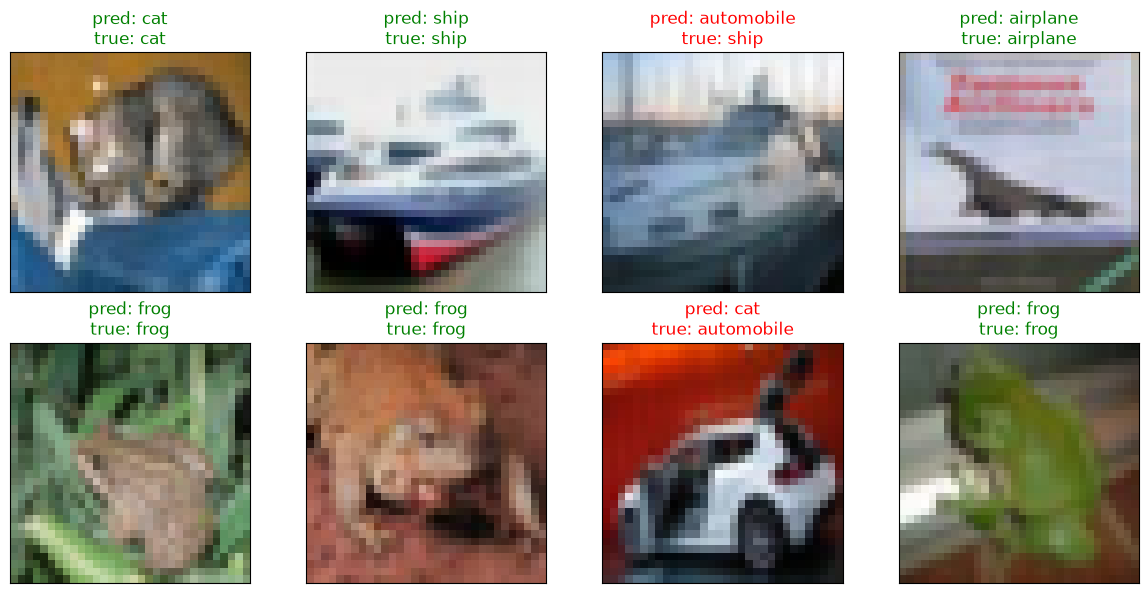

In [13]:
# Visual sanity check - look at real predictions on test images
import numpy as np

def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.cpu().numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

fig = plt.figure(figsize=(12, 6))
for i in range(8):
    ax = fig.add_subplot(2, 4, i+1, xticks=[], yticks=[])
    imshow(images[i])
    color = 'green' if preds[i] == labels[i] else 'red'
    ax.set_title(f"pred: {classes[preds[i]]}\ntrue: {classes[labels[i]]}", color=color)
plt.tight_layout()
plt.show()

### Test on Your Own Image

This is the part that actually answers "can it recognize a real object I give it?" — load any image file (a photo you take or download), run it through the same preprocessing the model was trained on, and see what it predicts.

**Important:** CIFAR-10 only knows these 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck. If you give it a photo of anything else (e.g. a laptop), it will still confidently guess one of these 10 — that's a real limitation of the model, not a bug.

In [14]:
from PIL import Image

# Reload the model fresh (so this section works standalone without rerunning training)
inference_model = CNN().to(device)
inference_model.load_state_dict(torch.load("cnn_cifar10.pth", map_location=device))
inference_model.eval()

def predict_image(image_path, model, transform, classes, device):
    """Load an image from disk, preprocess it, and return the predicted class + confidence."""
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize((32, 32))  # CIFAR-10 images are 32x32

    img_tensor = transform(img_resized).unsqueeze(0).to(device)  # add batch dimension

    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.nn.functional.softmax(output, dim=1)
        confidence, predicted = torch.max(probs, 1)

    predicted_class = classes[predicted.item()]
    confidence_pct = confidence.item() * 100

    # Show the image with the prediction
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {predicted_class} ({confidence_pct:.1f}% confidence)")
    plt.show()

    # Show top-3 predictions for extra insight
    top3_probs, top3_idx = torch.topk(probs, 3)
    print("Top 3 predictions:")
    for p, idx in zip(top3_probs[0], top3_idx[0]):
        print(f"  {classes[idx.item()]:10s}: {p.item()*100:.2f}%")

    return predicted_class, confidence_pct

In [ ]:
# Example usage: put an image (jpg/png) in the same folder as this notebook
# and change the filename below to test it

image_path = r"your_image.jpg" # <-- change this to your image's filename/path
predicted_class, confidence = predict_image(image_path, inference_model, transform, classes, device)